# Bean Leaf Lesions Classification

In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision import models
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = 'cuda'

In [44]:
train_df = pd.read_csv(r"datasets/bean_leaf/train.csv")
val_df = pd.read_csv(r"datasets/bean_leaf/val.csv")

train_df["image:FILE"] = "datasets/bean_leaf/" + train_df["image:FILE"]
val_df["image:FILE"] = "datasets/bean_leaf/" + val_df["image:FILE"]
train_df.head()

,image:FILE,category
0,datasets/bean_leaf/train/healthy/healthy_train...,0
1,datasets/bean_leaf/train/healthy/healthy_train...,0
2,datasets/bean_leaf/train/healthy/healthy_train...,0
3,datasets/bean_leaf/train/healthy/healthy_train...,0
4,datasets/bean_leaf/train/healthy/healthy_train...,0


In [45]:
train_df["category"].unique()

array([0, 1, 2])

In [46]:
print(train_df.shape)
print(val_df.shape)

(1034, 2)
(133, 2)


In [47]:
print(train_df["category"].value_counts())

category
2    348
1    345
0    341
Name: count, dtype: int64


In [48]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [49]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(dataframe["category"]).to(device)

    def __len__(self):
        return self.dataframe.shape[0]
    
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]
        image = Image.open(img_path)
        if self.transform:
            image = (self.transform(image) / 255.0).to(device)
        
        return image, label

In [50]:
train_dataset = CustomImageDataset(dataframe = train_df, transform=transform)
val_dataset = CustomImageDataset(dataframe = val_df, transform=transform)

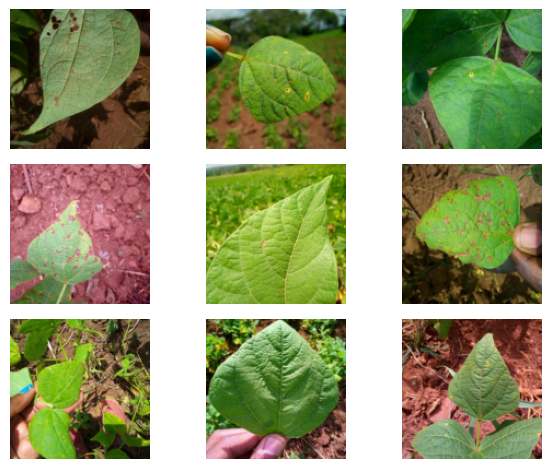

In [53]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)
for row in range(n_rows):
    for col in range(n_cols):
        image = train_dataset[np.random.randint(0, train_dataset.__len__())][0].cpu()
        axarr[row, col].imshow((image*255.0).squeeze().permute(1,2,0))
        axarr[row, col].axis('off')
plt.tight_layout()
plt.show()

In [54]:
LR = 1e-2
BATCH_SIZE = 4
EPOCHS = 15

In [55]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle=True)

In [56]:
googlenet_model = models.googlenet(weights='DEFAULT')

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to C:\Users\Praveen K/.cache\torch\hub\checkpoints\googlenet-1378be20.pth
100%|██████████| 49.7M/49.7M [00:12<00:00, 4.26MB/s]


In [57]:
for param in googlenet_model.parameters():
    param.requires_grad = True

In [58]:
googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [60]:
num_classes = len(train_df["category"].unique())
num_classes

3

In [61]:
googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_classes)
googlenet_model.fc

Linear(in_features=1024, out_features=3, bias=True)

In [62]:
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [64]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr = LR)

total_loss_train_plot = [] 
total_acc_train_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = googlenet_model(inputs)
        train_loss = criterion(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()
        train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
        total_acc_train += train_acc
        optimizer.step()

    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__()* 100, 4))

    print(f'''Epoch no. {epoch+1}/{EPOCHS} Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy: {round((total_acc_train/train_dataset.__len__()) * 100, 4)}''')


Epoch no. 1/15 Train Loss: 0.316 Train Accuracy: 36.8472
Epoch no. 2/15 Train Loss: 0.2991 Train Accuracy: 38.2979
Epoch no. 3/15 Train Loss: 0.2885 Train Accuracy: 40.5222
Epoch no. 4/15 Train Loss: 0.2806 Train Accuracy: 39.5551
Epoch no. 5/15 Train Loss: 0.2704 Train Accuracy: 45.1644
Epoch no. 6/15 Train Loss: 0.2625 Train Accuracy: 47.3888
Epoch no. 7/15 Train Loss: 0.2701 Train Accuracy: 44.294
Epoch no. 8/15 Train Loss: 0.259 Train Accuracy: 47.1954
Epoch no. 9/15 Train Loss: 0.2466 Train Accuracy: 51.6441
Epoch no. 10/15 Train Loss: 0.2325 Train Accuracy: 53.1915
Epoch no. 11/15 Train Loss: 0.2289 Train Accuracy: 58.0271
Epoch no. 12/15 Train Loss: 0.212 Train Accuracy: 62.3791
Epoch no. 13/15 Train Loss: 0.1927 Train Accuracy: 68.8588
Epoch no. 14/15 Train Loss: 0.1832 Train Accuracy: 66.8279
Epoch no. 15/15 Train Loss: 0.1786 Train Accuracy: 72.6306
